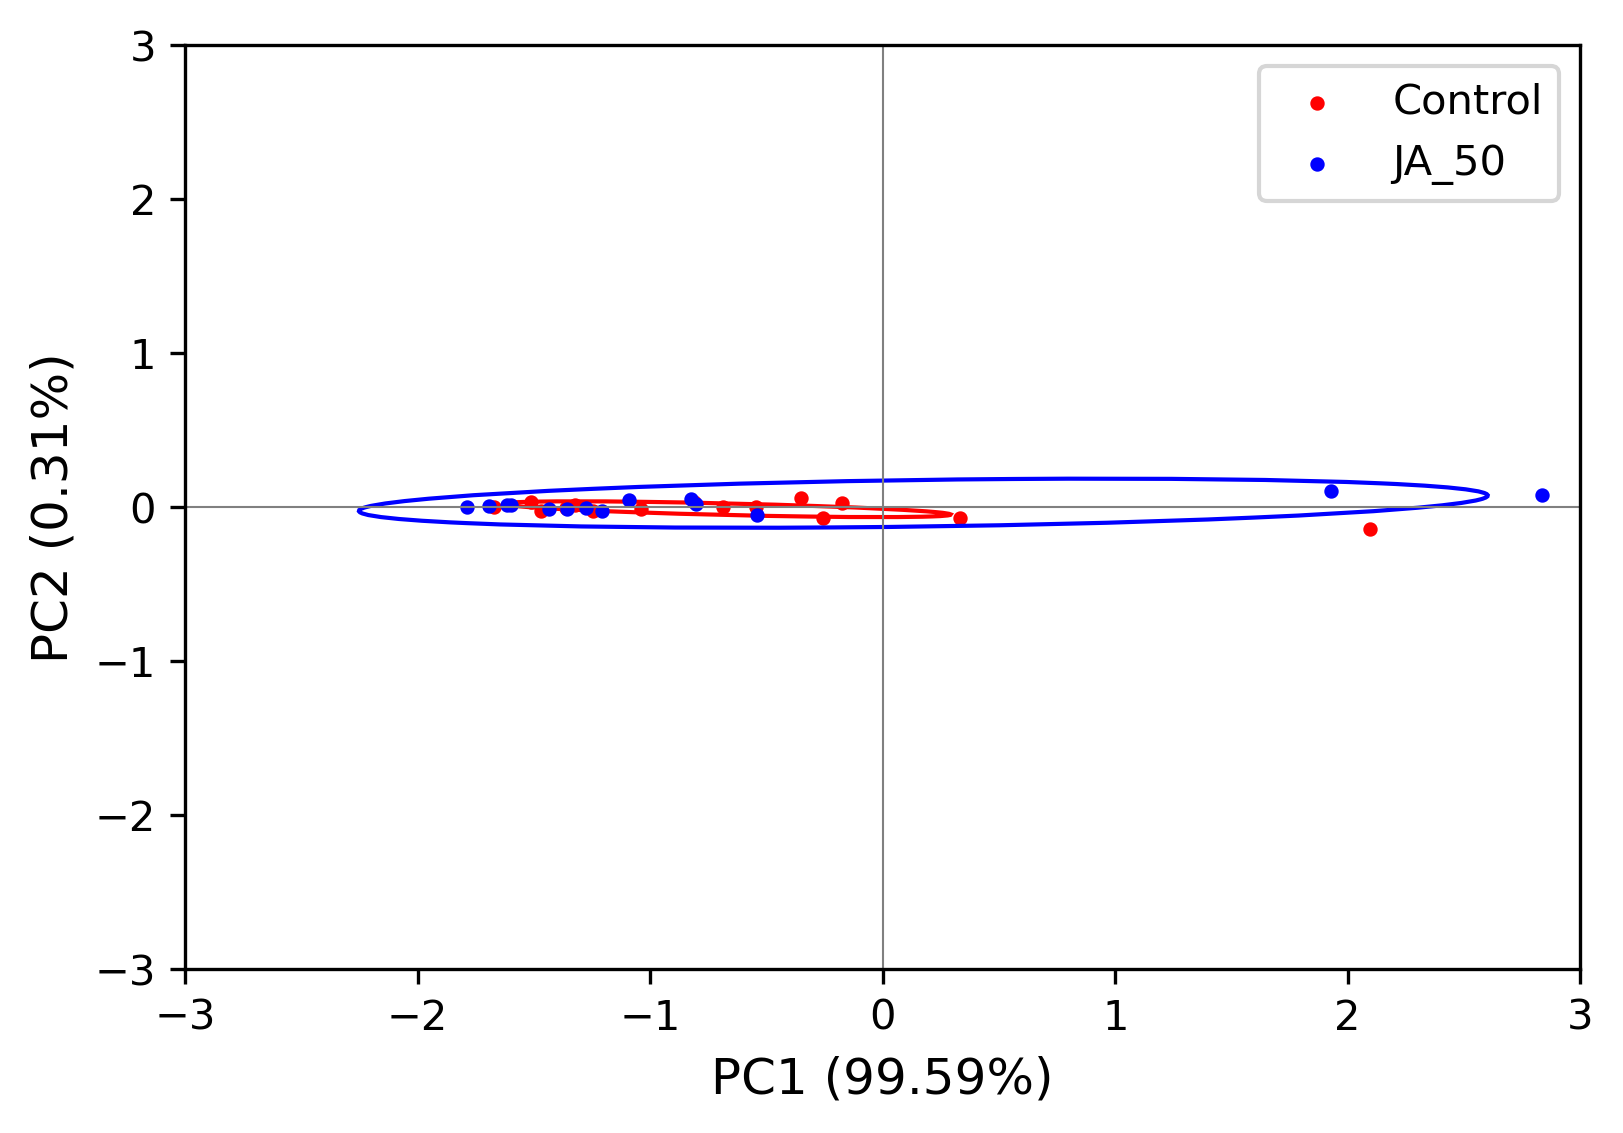

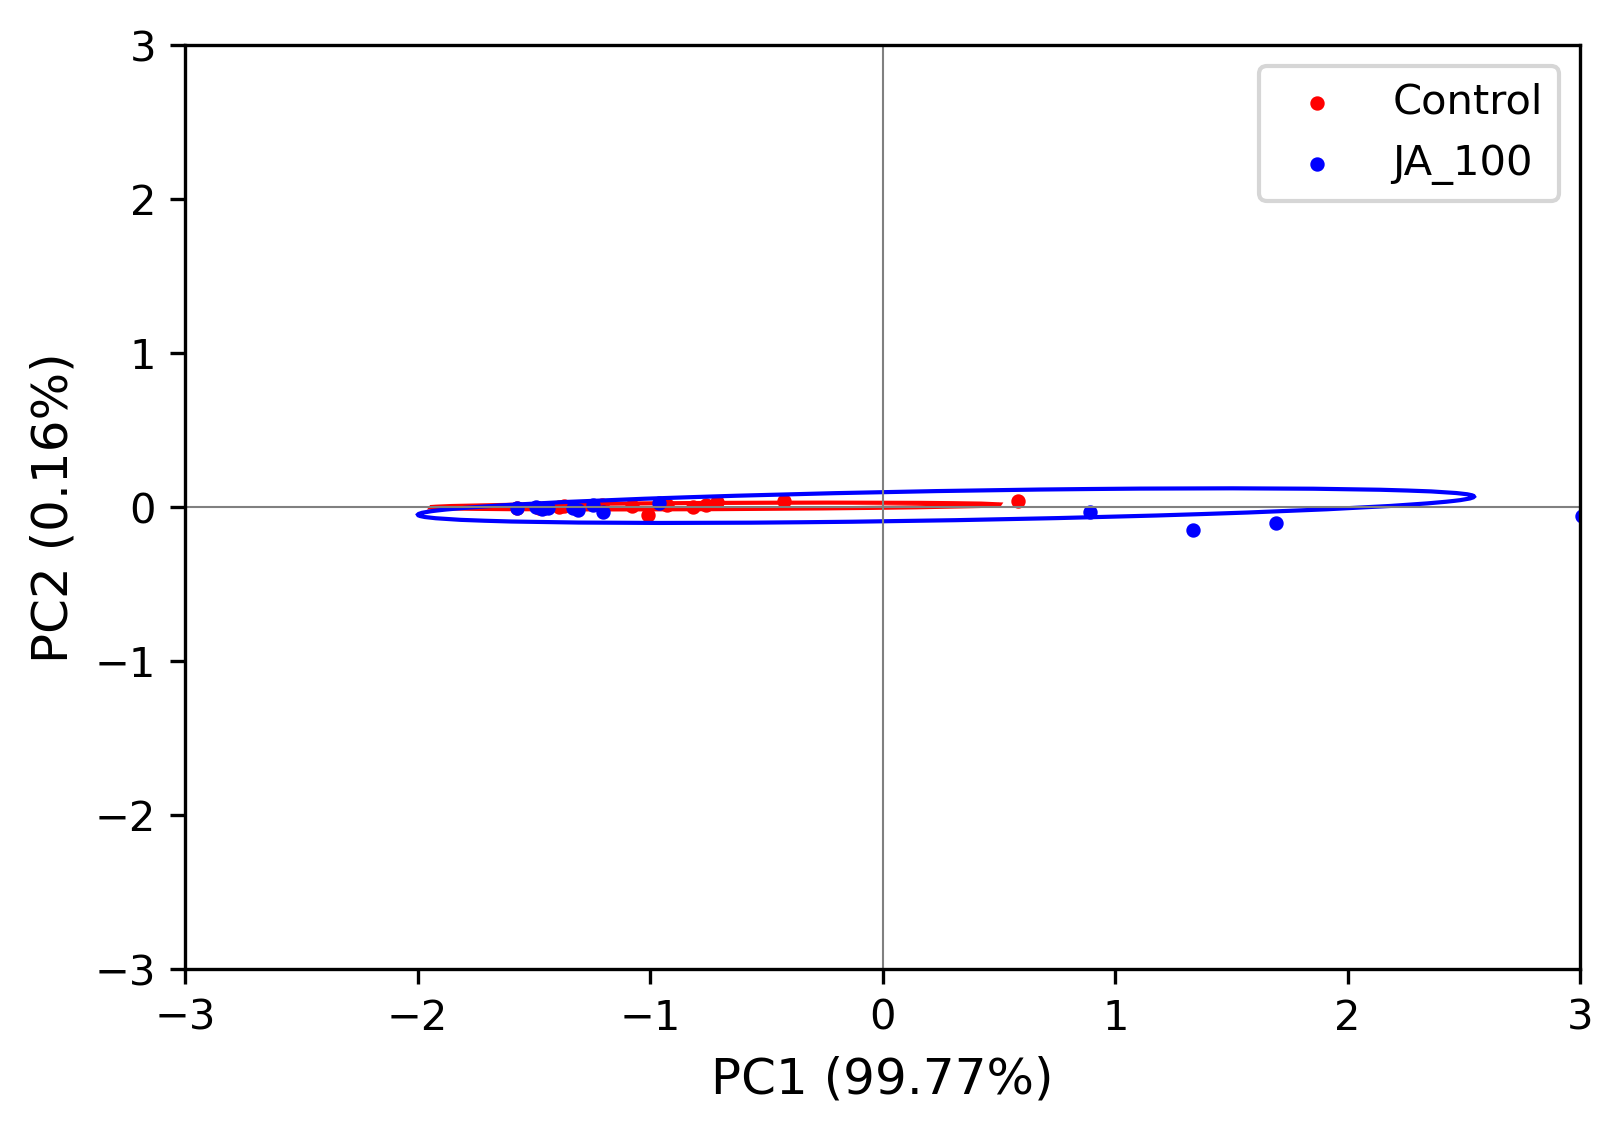

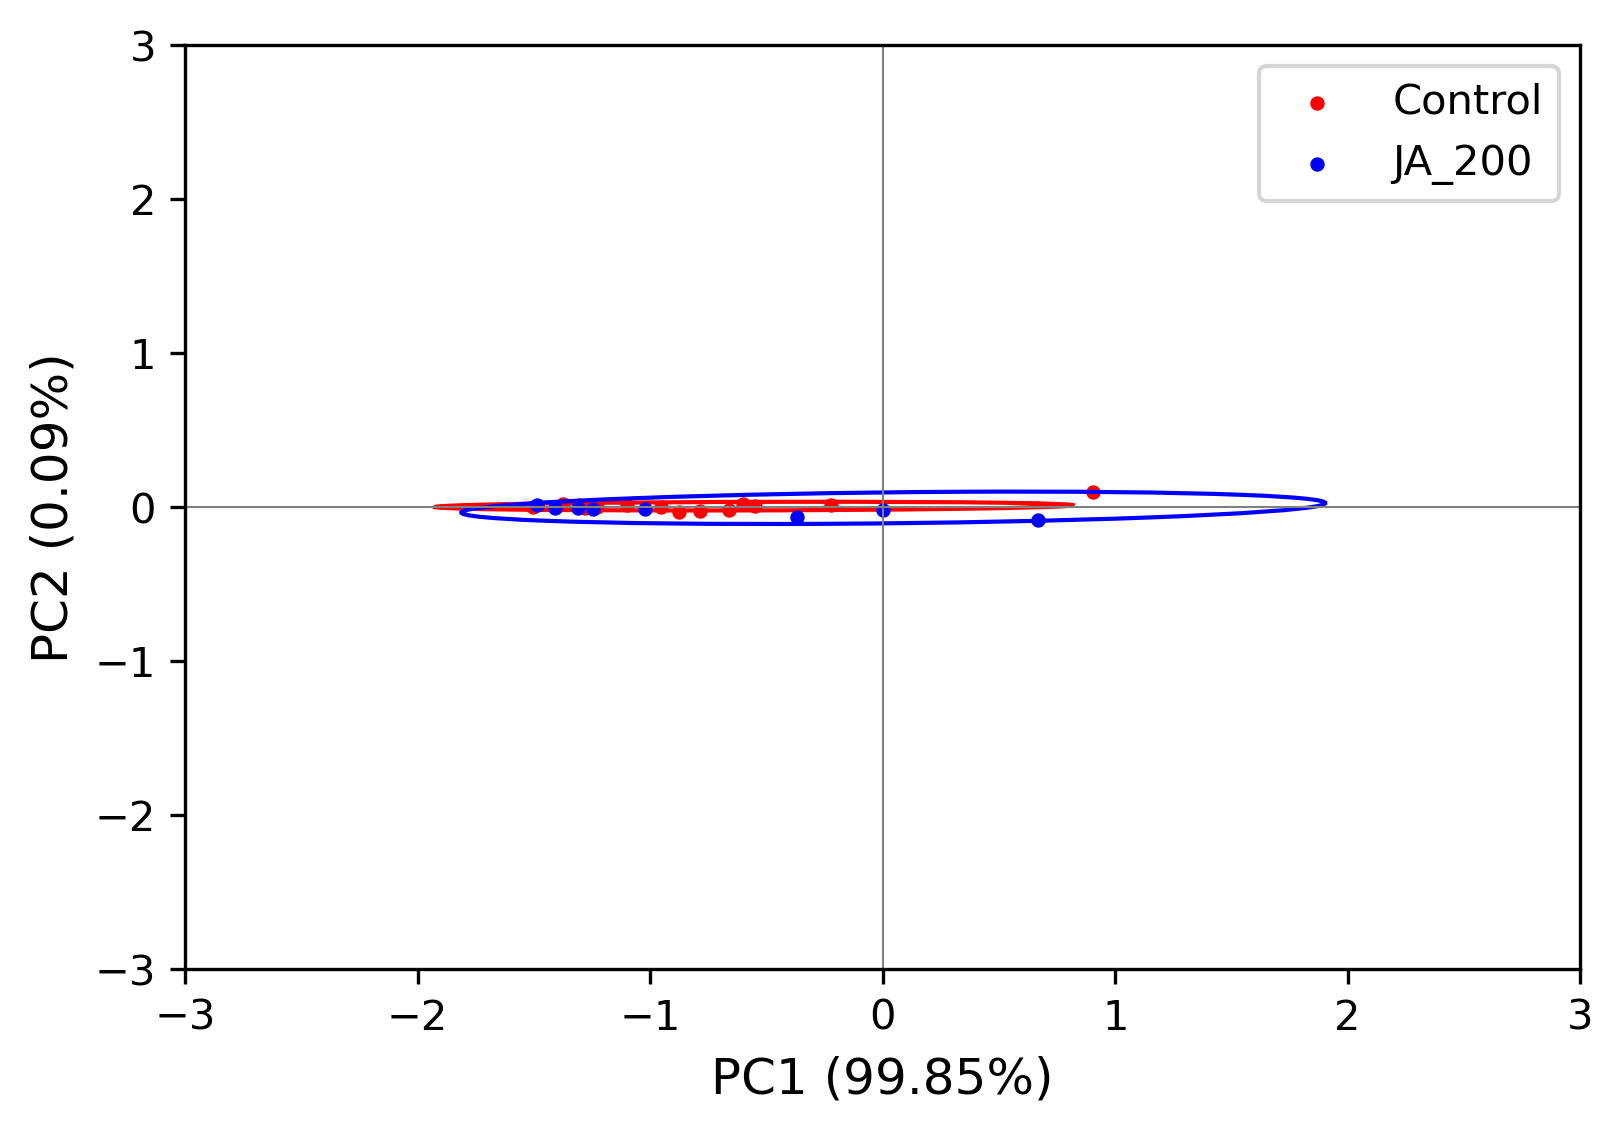

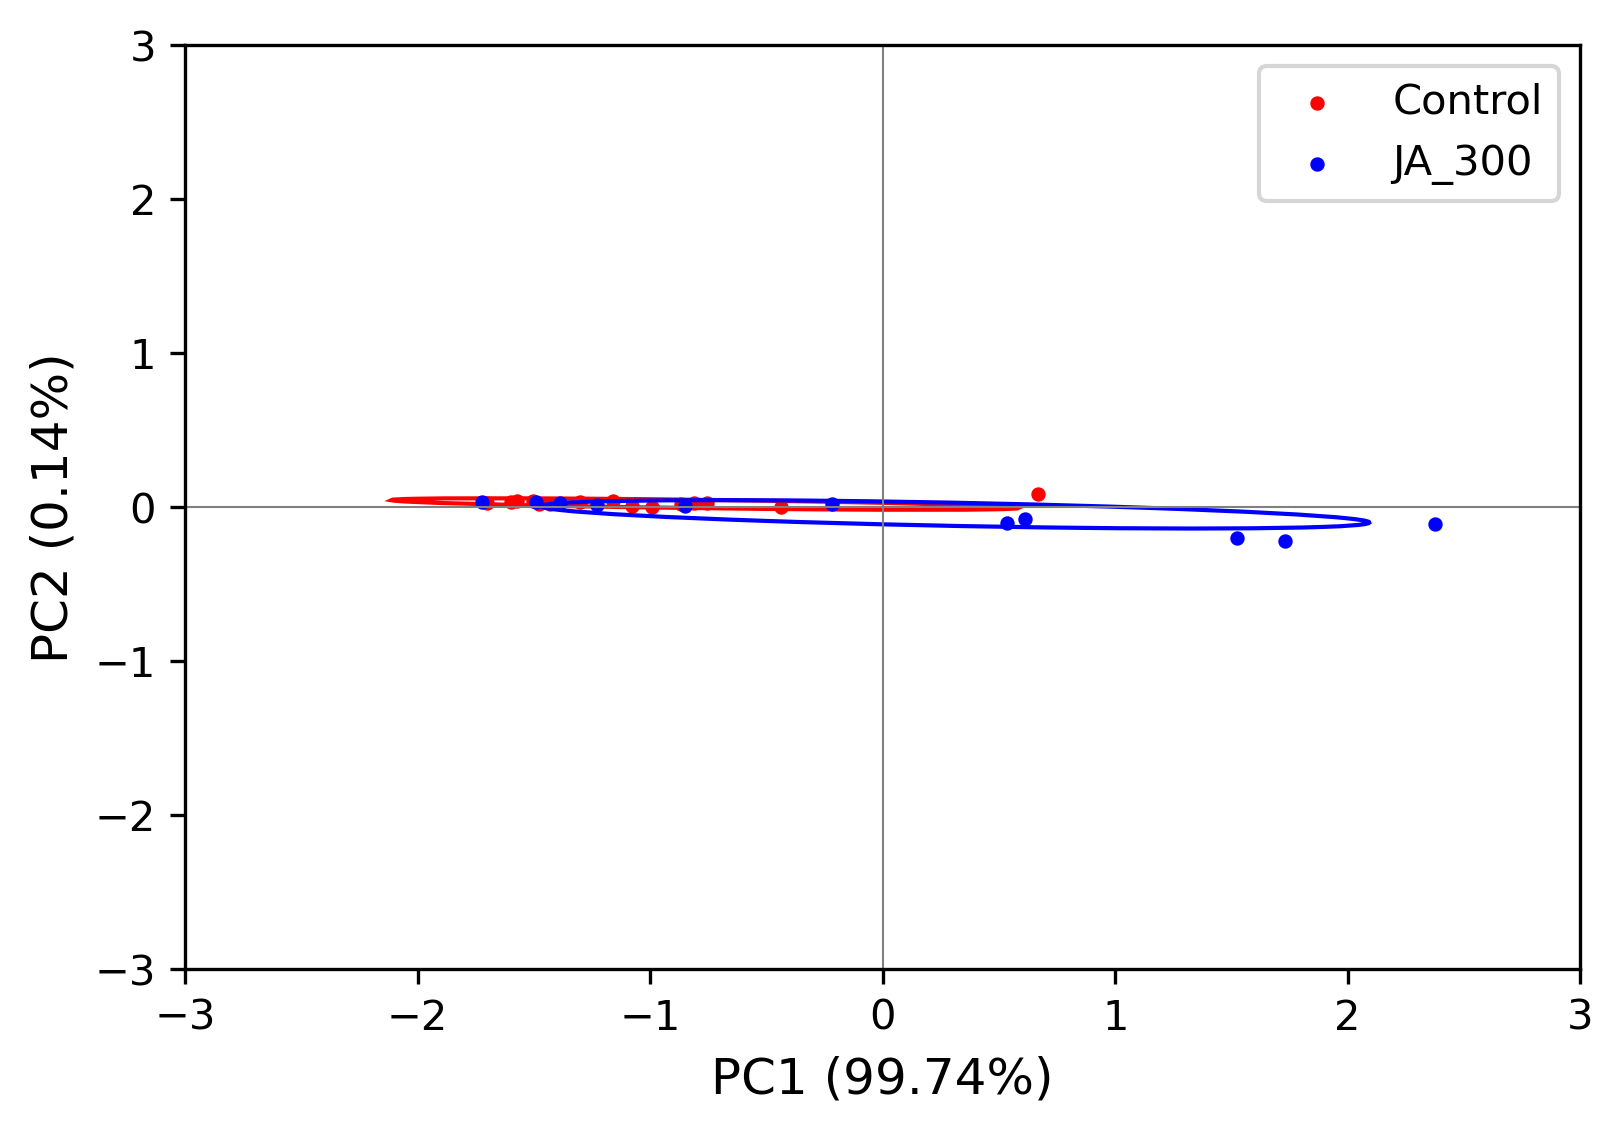

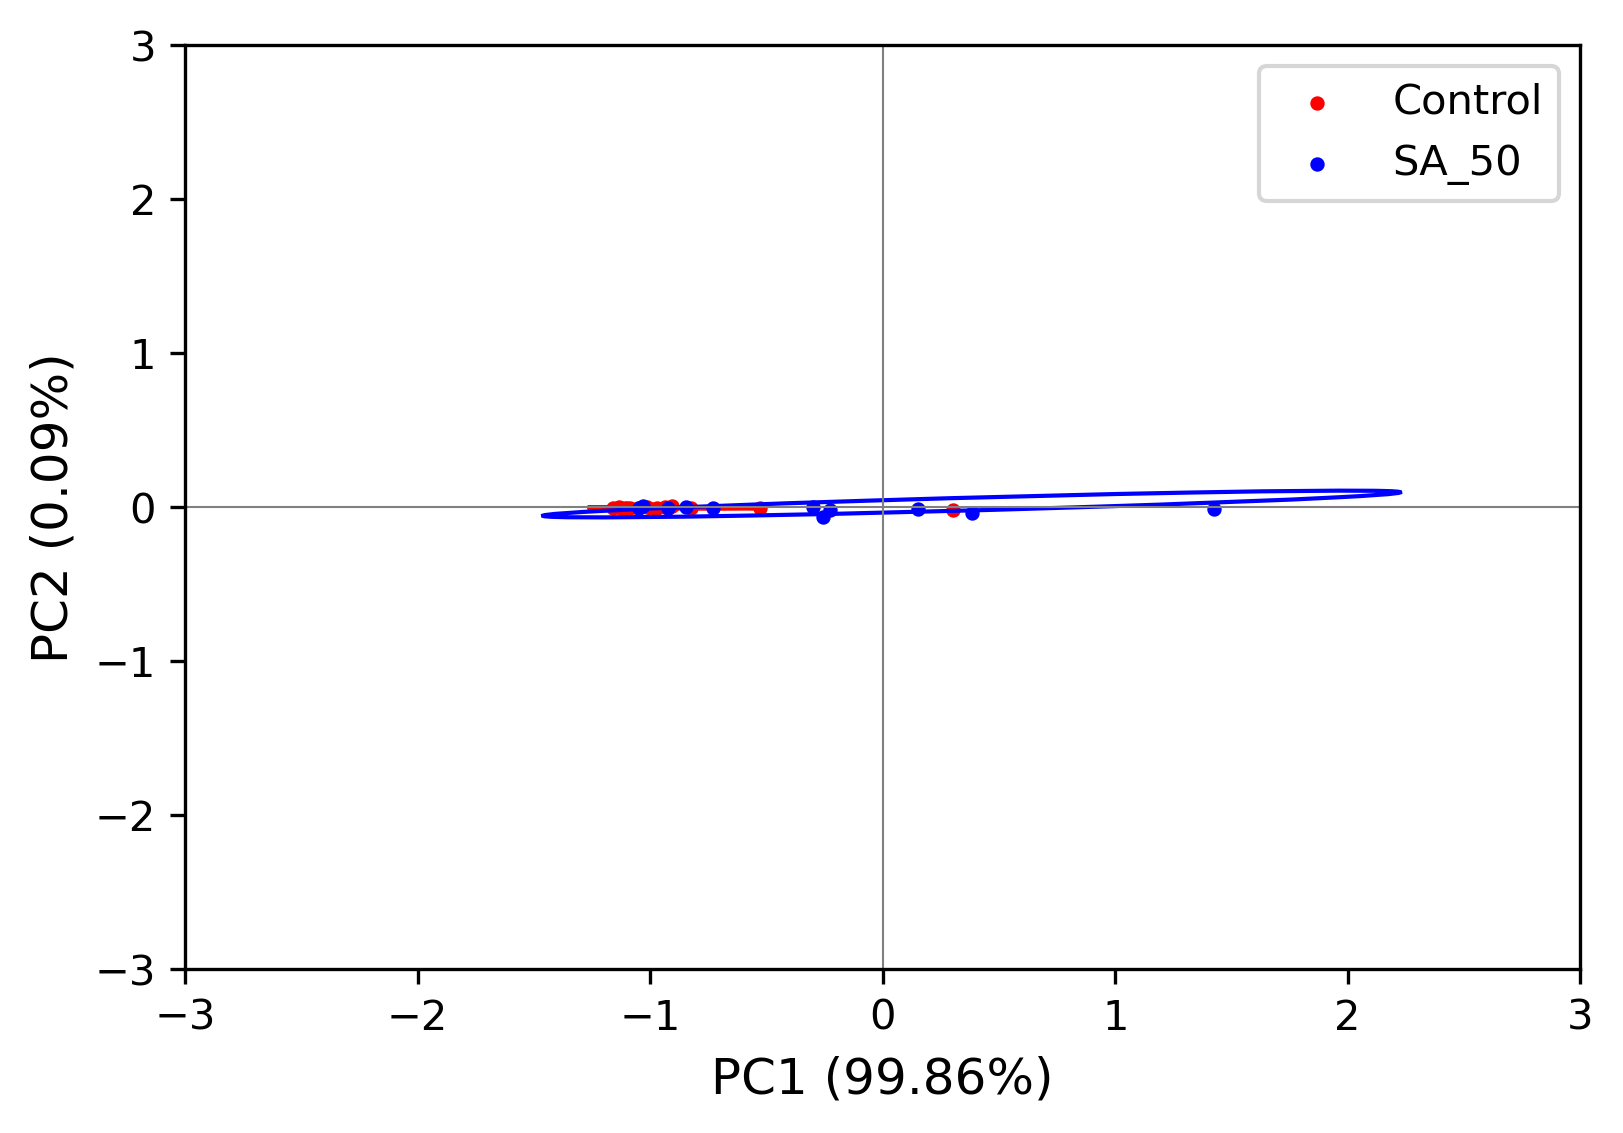

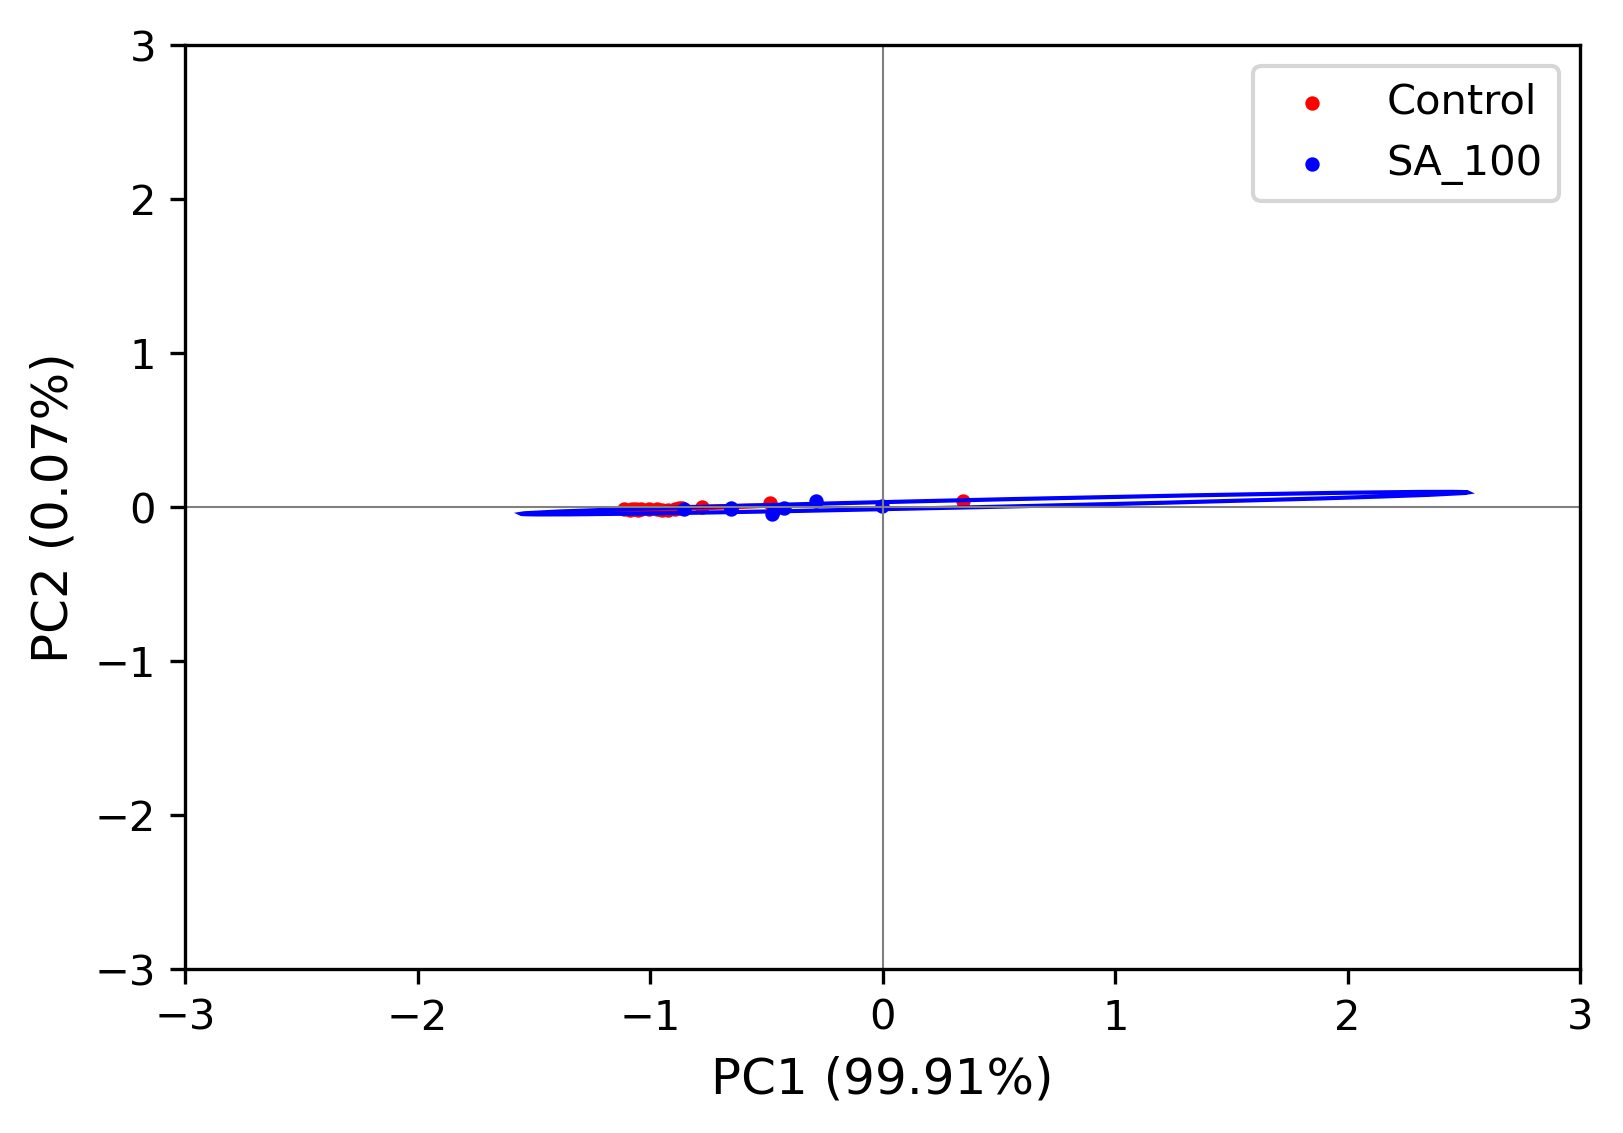

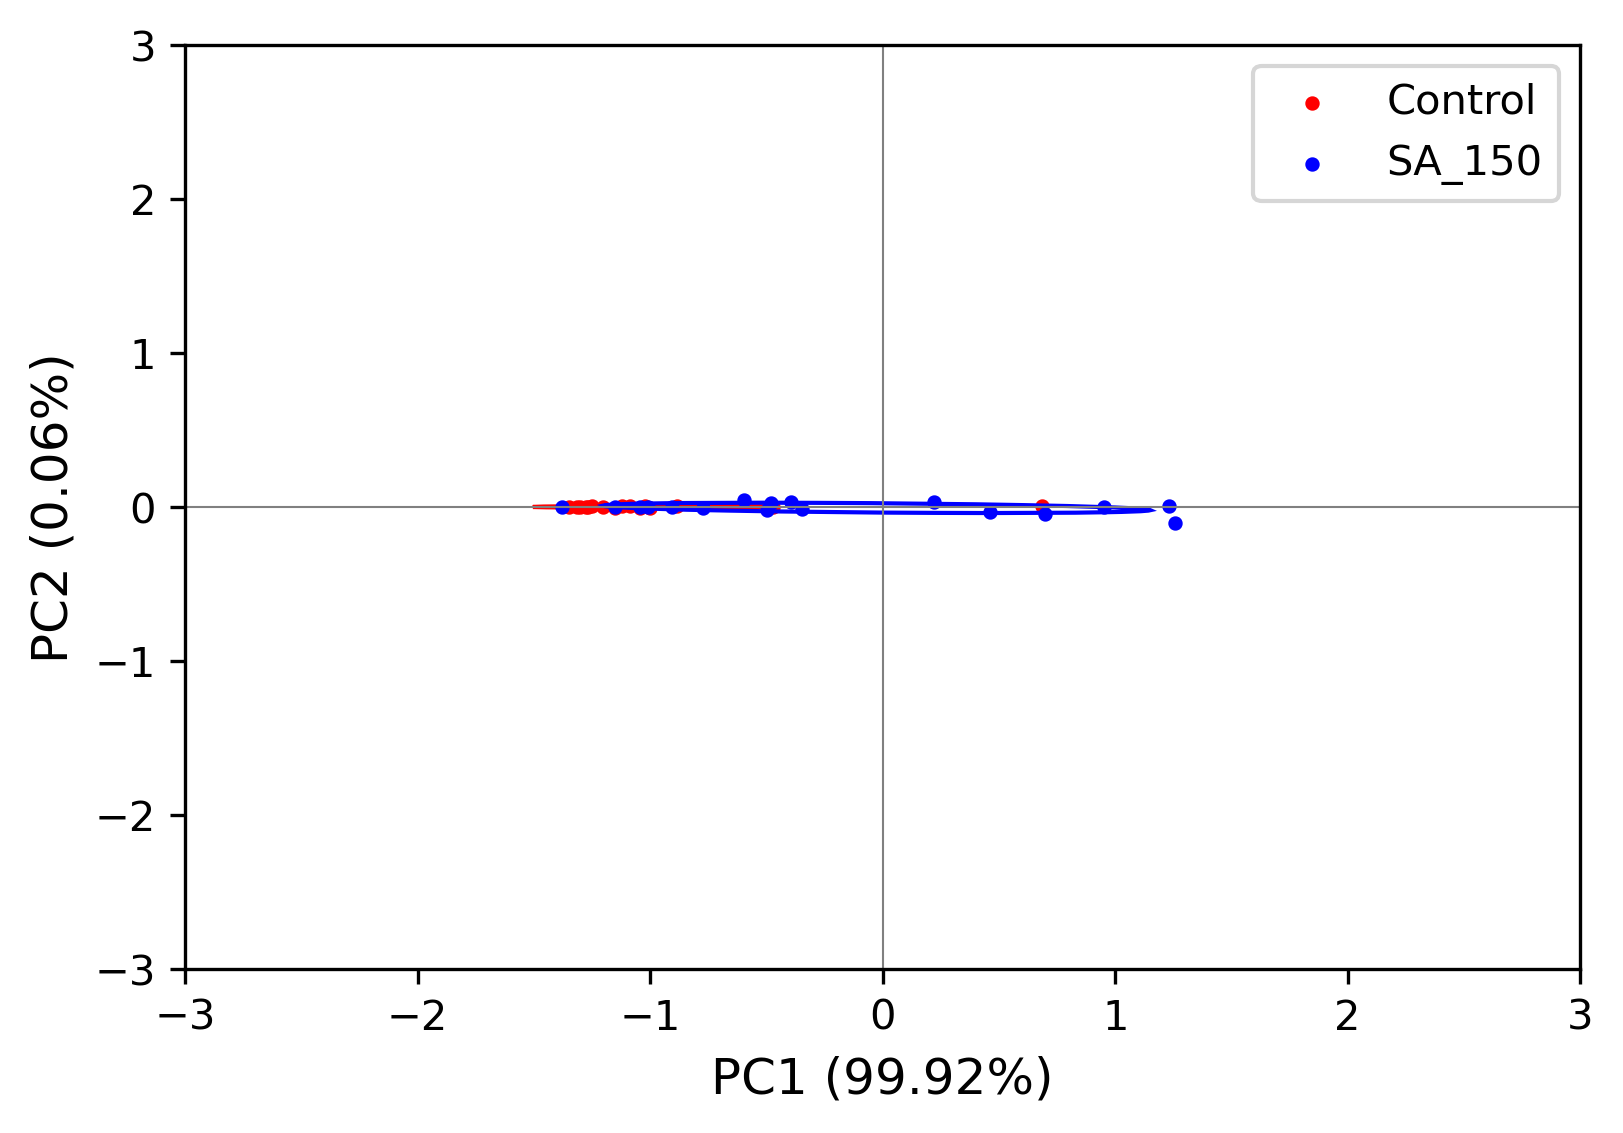

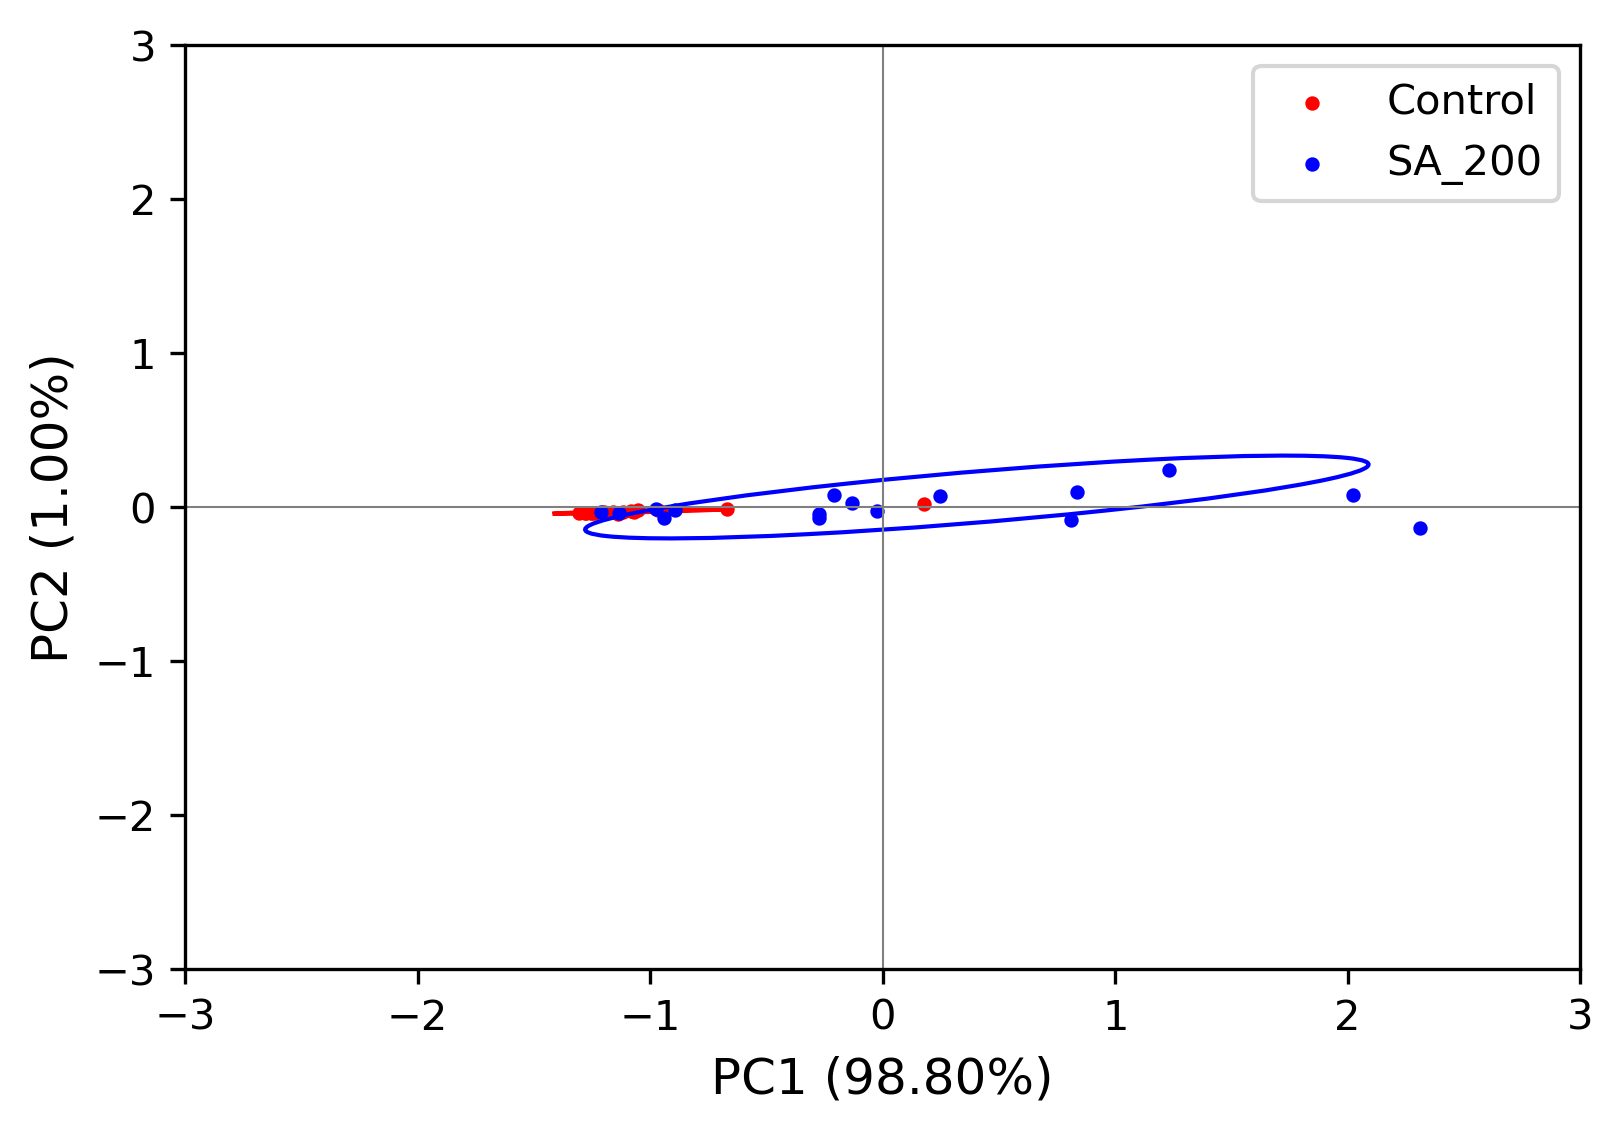

In [4]:
import pandas as pd  
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib import transforms
import numpy as np

# Mapping labels to corresponding CSV files
file_mapping = {
    'Control': 'replicates_Control.csv',
    'JA_50': 'replicates_JA50.csv',
    'JA_100': 'replicates_JA100.csv',
    'JA_200': 'replicates_JA200.csv',
    'JA_300': 'replicates_JA300.csv',
    'SA_50': 'replicates_SA50.csv',
    'SA_100': 'replicates_SA100.csv',
    'SA_150': 'replicates_SA150.csv',
    'SA_200': 'replicates_SA200.csv'
}

# Define the pairings for PCA
pairings = [
    ('Control', 'JA_50'), ('Control', 'JA_100'), ('Control', 'JA_200'),
    ('Control', 'JA_300'), ('Control', 'SA_50'), ('Control', 'SA_100'),
    ('Control', 'SA_150'), ('Control', 'SA_200')
]

# Load the CSV files into a dictionary of DataFrames
dfs = {label: pd.read_csv(file_mapping[label]) for label in file_mapping}

# Function to remove outliers beyond +6.5 range on x-axis (PC1)
def remove_outliers(df, max_x=6.5):
    return df[abs(df['PC1']) <= max_x]

# Function to create a confidence ellipse
def confidence_ellipse(x, y, ax, n_std=3.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, facecolor=facecolor, **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ellipse

# Loop through each pairing and plot PCA
for pairing in pairings:
    group1, group2 = pairing

    # Combine the DataFrames for the two groups
    df_combined = pd.concat([dfs[group1], dfs[group2]], keys=[group1, group2], ignore_index=False)

    # Select the columns for PCA
    columns = ["Replicate 1", "Replicate 2", "Replicate 3", "Replicate 4", "Replicate 5"]
    df_selected = df_combined[columns]

    # Impute missing values with column mean
    imputer = SimpleImputer(strategy='mean')
    df_imputed = imputer.fit_transform(df_selected)

    # Standardize the features to have mean=0 and variance=1
    scaler = StandardScaler().fit(df_imputed)
    df_standardized = scaler.transform(df_imputed)

    # Perform PCA with 2 components
    pca = PCA(n_components=2)
    principalComponents = pca.fit_transform(df_standardized)

    # Convert numpy array to pandas DataFrame
    df_pca = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])
    df_pca['label'] = df_combined.index.get_level_values(0)

    # Remove outliers
    df_pca_filtered = remove_outliers(df_pca, max_x=6.5)

    # Calculate explained variance
    explained_variance = pca.explained_variance_ratio_
    x_label = f'PC1 ({explained_variance[0] * 100:.2f}%)'
    y_label = f'PC2 ({explained_variance[1] * 100:.2f}%)'

    # Plot the 2D PCA
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    for label in [group1, group2]:
        indicesToKeep = df_pca_filtered['label'] == label
        ax.scatter(df_pca_filtered.loc[indicesToKeep, 'PC1'],
                   df_pca_filtered.loc[indicesToKeep, 'PC2'],
                   c='red' if label == group1 else 'blue',
                   label=label, s=6)
        # Add confidence ellipse
        ellipse = confidence_ellipse(
            df_pca_filtered.loc[indicesToKeep, 'PC1'],
            df_pca_filtered.loc[indicesToKeep, 'PC2'],
            ax,
            n_std=1.0,
            edgecolor='red' if label == group1 else 'blue'
        )
        ax.add_patch(ellipse)

    # Set fixed limits for both axes
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

    # Set axis labels and title
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(f'')
    ax.legend()
    plt.show()
